In [ ]:
# 라이브러리 import 및 버전 확인
import tensorflow as tf
import numpy as np
import pandas as pd

print("TensorFlow 버전:", tf.__version__)
print("NumPy 버전:", np.__version__)
print("Pandas 버전:", pd.__version__)


# 데이터 다운로드
path_to_train_file = tf.keras.utils.get_file('train.txt',
                                             'https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt')


path_to_test_file = tf.keras.utils.get_file('test.txt',
                                            'https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt')

TensorFlow 버전: 2.21.0
NumPy 버전: 2.4.4
Pandas 버전: 3.0.2


In [11]:
train_text = open(path_to_train_file, 'rb').read().decode(encoding='utf-8')
test_text = open(path_to_test_file, 'rb').read().decode(encoding='utf-8')

print(f'train text 길이: {len(train_text)} characters') 
print(f'test text 길이: {len(test_text)} characters')
print('test text의 처음 500자 출력:\n', test_text[:500]) 

train text 길이: 6937271 characters
test text 길이: 2318260 characters
test text의 처음 500자 출력:
 id	document	label
6270596	굳 ㅋ	1
9274899	GDNTOPCLASSINTHECLUB	0
8544678	뭐야 이 평점들은.... 나쁘진 않지만 10점 짜리는 더더욱 아니잖아	0
6825595	지루하지는 않은데 완전 막장임... 돈주고 보기에는....	0
6723715	3D만 아니었어도 별 다섯 개 줬을텐데.. 왜 3D로 나와서 제 심기를 불편하게 하죠??	0
7898805	음악이 주가 된, 최고의 음악영화	1
6315043	진정한 쓰레기	0
6097171	마치 미국애니에서 튀어나온듯한 창의력없는 로봇디자인부터가,고개를 젖게한다	0
8932678	갈수록 개판되가는 중국영화 유치하고 내용없음 폼잡다 끝남 말도안되는 무기에 유치한cg남무 아 그립다 동사서독같은 영화가 이건 3류아류작이다	0
6242223	이별의 아픔뒤에 찾아오는 새로운 인연의 기쁨 But, 모든 사람이 그렇지는 않네..	1
7462111	괜찮네요오랜만포켓몬스터잼밌어요	1
8425305	한국독립영화의


In [40]:
#  Y(정답 라벨) 데이터 만들기
train_Y = np.array([
    [int(row.split('\t')[2])] # 3. 라벨 값 추출
    for row in train_text.split('\n')[1:] # 1. 첫 번째 줄(0) 제외, 한 줄씩 순회
    if row.count('\t') > 0 # 2. 탭 없는 줄 제외
])

test_Y = np.array([
    [int(row.split('\t')[2])]
    for row in test_text.split('\n')[1:]
    if row.count('\t') > 0
])

print("train_Y shape:", train_Y.shape)
print("test_Y shape:", test_Y.shape)
print("train_Y sample:", train_Y[:10])

train_Y shape: (150000, 1)
test_Y shape: (50000, 1)
train_Y sample: [[0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [1]]


In [ ]:
import re

def clean_str(string): 
    string = re.sub(r"[^가-힣A-Za-z0-9(),!?\'\`]", " ", string) # 한글, 영어, 숫자, 일부 특수문자 제외한 모든 문자 제거
    string = re.sub(r"\'s", " \'s", string) # 
    string = re.sub(r"\'ve", " \'ve", string) 
    string = re.sub(r"n\'t", " n\'t", string)
    string = re.sub(r"\'re", " \'re", string)
    string = re.sub(r"\'d", " \'d", string)
    string = re.sub(r"\'ll", " \'ll", string)
    string = re.sub(r",", " , ", string)
    string = re.sub(r"!", " ! ", string)
    string = re.sub(r"\(", " \( ", string)
    string = re.sub(r"\)", " \) ", string) 
    string = re.sub(r"\?", " \? ", string)
    string = re.sub(r"\s{2,}", " ", string)
    string = re.sub(r"\'{2,}", "\'", string)
    string = re.sub(r"\'", "", string)

    return string.lower()

# 리뷰 텍스트만 추출 
train_text_X = [row.split('\t')[1] 
                for row in train_text.split('\n')[1:] 
                if row.count('\t') > 0]

#clean_str을 이용해 리뷰 텍스트 전처리
train_text_X = [clean_str(sentence) for sentence in train_text_X]

# 문장을 띄어쓰기 단위로 단어 분리
sentences = [sentence.split(' ') for sentence in train_text_X]


# 학습 데이터 10개 샘플 출력
for i in range(10):
    print(sentences[i])

['아', '더빙', '진짜', '짜증나네요', '목소리']
['흠', '포스터보고', '초딩영화줄', '오버연기조차', '가볍지', '않구나']
['너무재밓었다그래서보는것을추천한다']
['교도소', '이야기구먼', '솔직히', '재미는', '없다', '평점', '조정']
['사이몬페그의', '익살스런', '연기가', '돋보였던', '영화', '!', '스파이더맨에서', '늙어보이기만', '했던', '커스틴', '던스트가', '너무나도', '이뻐보였다']
['막', '걸음마', '뗀', '3세부터', '초등학교', '1학년생인', '8살용영화', '별반개도', '아까움', '']
['원작의', '긴장감을', '제대로', '살려내지못했다', '']
['별', '반개도', '아깝다', '욕나온다', '이응경', '길용우', '연기생활이몇년인지', '정말', '발로해도', '그것보단', '낫겟다', '납치', '감금만반복반복', '이드라마는', '가족도없다', '연기못하는사람만모엿네']
['액션이', '없는데도', '재미', '있는', '몇안되는', '영화']
['왜케', '평점이', '낮은건데', '\\?', '꽤', '볼만한데', '헐리우드식', '화려함에만', '너무', '길들여져', '있나', '\\?', '']


In [ ]:
VOCAB_SIZE = 2000   # 단어 사전 크기
MAX_LEN = 25        # 최대 문장 길이 (패딩 기준)

#전처리 담당 레이어 정의
vectorize_layer = tf.keras.layers.TextVectorization(
    standardize='lower_and_strip_punctuation',  # 소문자 변환 + 구두점 제거
    split='whitespace',                         # 띄어쓰기 기준 토큰화
    max_tokens=VOCAB_SIZE,                      # 단어 사전 크기
    output_mode='int',                          # 정수 인코딩
    output_sequence_length=MAX_LEN              # 자동 패딩
)

# 텍스트로 단어 사전 구축 (단어:정수 매핑)
vectorize_layer.adapt(train_text_X)

# 단어 사전을 이용해 텍스트 데이터를 정수 시퀀스로 변환
train_X = vectorize_layer(train_text_X)

print(train_X[0])

print(train_X[:5])

tf.Tensor(
[  23  902    5    1 1097    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0], shape=(25,), dtype=int64)
tf.Tensor(
[[  23  902    5    1 1097    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0]
 [ 586    1    1    1    1    1    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0]
 [   1    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0]
 [   1    1   68  345   28   33    1    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0]
 [   1    1  102    1    2    1    1  844    1    1  570    1    0    0
     0    0    0    0    0    0    0    0    0    0    0]], shape=(5, 25), dtype=int64)


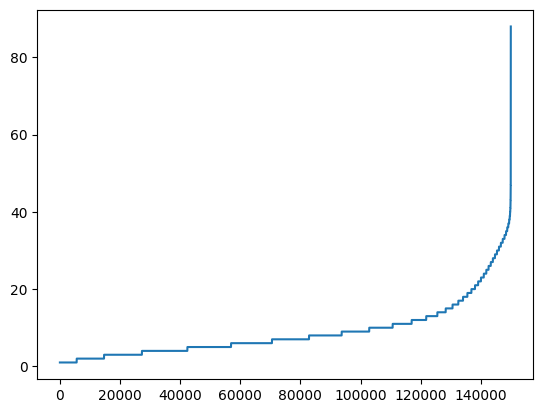

In [ ]:
import matplotlib.pyplot as plt
sentence_len = [len(sentence) for sentence in sentences] # 각 문장의 단어 수 계산
sentence_len.sort() # 단어 수 기준 정렬
plt.plot(sentence_len)
plt.show()

In [38]:
print(sum([int(l<=25) for l in sentence_len]))

142587
